In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
from datetime import datetime
from plotnine import ggplot, aes
import plotnine as p9

plt.style.use("ggplot")

output = "output/csv/"
input = "input/"
figures = "figures/"
uk = ["England", "Scotland", "Wales", "Northern Ireland"]

students = pd.read_excel(f"{input}students.xlsx", sheet_name="Students")
jobs = pd.read_excel(f"{input}students.xlsx", sheet_name="Jobs")

string_columns = ["Sector"]
# jobs[string_columns] = jobs[string_columns].astype(str).strip()

students = students[students.Year != 2020]

current_year = datetime.now().year
to_exclude = [0, "0", np.nan, "nan", "None", "none", "", "Not Found", "Error"]

# add end date for all students
names_to_exclude = []
jobs.end_date = np.nan
for name in jobs.Name.unique():
    if name in students.Name.unique():
        relevant_row = students.loc[students.Name == name]
        # Check if the relevant row is empty
        year = relevant_row["Thesis Year"].values[0]
        if pd.isna(year):
            names_to_exclude.append(name)
        else:
            jobs.loc[jobs.Name == name, "end_date"] = year

    else:
        print(f"Name {name} not found in students list")

# remove students with no end date
jobs = jobs[~jobs.Name.isin(names_to_exclude)]

# get the year only of the start date, as an int
jobs["start_year"] = jobs["Start date"].copy()
jobs["start_year"] = (
    jobs["start_year"].astype(str).str.extract(r"(\d{4})")[0].astype(float)
)

jobs["years_to_job_start"] = jobs.apply(
    lambda x: x.start_year - x.end_date
    if x.end_date != np.nan and x.start_year != np.nan
    else np.nan,
    axis=1,
)

jobs['years_since'] = jobs.apply(
    lambda x: current_year - x.end_date
    if x.end_date != np.nan
    else np.nan,
    axis=1,
)

# remove jobs before end date
jobs = jobs[jobs.years_to_job_start >= 0]

In [79]:
jobs

,ID,Name,Forename,Surname,Year,Job Title,Department,Company,Start date,End date,...,Continent,Country,City,Site,Unnamed: 15,Unnamed: 16,end_date,start_year,years_to_job_start,years_since
3,LSI20021,Danny Axford,Danny,Axford,2002,Academic,Department of Electronic and Electrical Engine...,UCL,2007-01-01 00:00:00,2008-06-01 00:00:00,...,NaN,NaN,NaN,NaN,2001-01-01 00:00:00,2002-01-01 00:00:00,2007.0,2007.0,0.0,18.0
5,LSI2013337,Ben Lambert,Ben,Lambert,2013,Academic Director of Schmidt Futeres,NaN,University of Oxford,2023-09-01 00:00:00,NaN,...,Europe,England,Oxford,https://www.linkedin.com/in/ben-lambert-693363...,2002-01-01 00:00:00,2004-01-01 00:00:00,2017.0,2023.0,6.0,8.0
8,LSI2008129,Ivor Simpson,Ivor,Simpson,2008,Academic Lead,NaN,Sussex AI,2023-10-01 00:00:00,NaN,...,Europe,England,Brighton,https://www.linkedin.com/in/ivor-simpson-9a21b...,2003-01-01 00:00:00,2004-01-01 00:00:00,2012.0,2023.0,11.0,13.0
11,LSI200560,Ann Harvey,Ann,Harvey,2005,Academic Research Fellow,NaN,Medical School Cardiff,2010-10-01 00:00:00,2014-11-01 00:00:00,...,NaN,NaN,NaN,https://www.linkedin.com/in/ann-harvey?lipi=ur...,2005-01-01 00:00:00,2005-01-01 00:00:00,2009.0,2010.0,1.0,16.0
12,DTPiCASE2015492,Maria Ordovas-Montanes,Maria,Ordovas-Montanes,2015,Academic Support Researcher and Evaluator,NaN,University of the arts London,2021-05-01 00:00:00,2022-12-01 00:00:00,...,NaN,NaN,NaN,https://www.linkedin.com/in/maria-ordovas-mont...,2005-01-01 00:00:00,2022-01-01 00:00:00,2021.0,2021.0,0.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4855,LSI200311,Martin Bishop,Martin,Bishop,2003,Welcome Trust Postdoctoral research Fellow,NaN,University of Oxford,2008-10-01 00:00:00,2012-08-01 00:00:00,...,NaN,NaN,NaN,https://www.linkedin.com/in/martin-bishop-18a2...,NaN,NaN,2008.0,2008.0,0.0,17.0
4857,LSI200445,Gary Mirams,Gary,Mirams,2004,Wellcome Trust Senior Research Fellow,NaN,University of Nottingham,2019-02-01 00:00:00,NaN,...,Europe,England,Nottingham,https://www.linkedin.com/in/garymirams?lipi=ur...,NaN,NaN,2008.0,2019.0,11.0,17.0
4881,SBM2014434,Melodie Richardson,Melodie,Richardson,2014,Zurich Enterprise Challenge Finalist,NaN,Zurich Insurance Company Ltd,2018-02-01 00:00:00,2018-09-01 00:00:00,...,Europe,Germany,Berlin,https://www.linkedin.com/in/melodie-richardson...,2019-09-01 00:00:00,2015-09-01 00:00:00,2018.0,2018.0,0.0,7.0
4884,SYSBIO2008133,Gareth Blades,Gareth,Blades,2008,NaN,NaN,Amati Global Investors,2019-07-01 00:00:00,NaN,...,Europe,Scotland,Edinburgh,https://www.linkedin.com/in/gareth-blades-90b5...,Unknown,NaN,2014.0,2019.0,5.0,11.0


# Alumni Project Dashboard
## Summary
This dashboard contains information about the data collected and analysed
as part of the alumni project. I have grouped plots and summaries by theme
which you can access using the dropdowns (hopefully)!

## Data collection summary

Because part of the project is to collect and clean data, I'll start by demonstrating
the progress made in the data collection. 

### What is the structure of the data?

The data is stored in an Excel spreadsheet. There are three areas of data collection:
- Alumni information: each student is assigned a unique identifier. Their course, prior institutions and current location are listed.
- Alumni jobs: for each alumnus, this records (where known) each job they have held since leaving the DTC, including employer, title, start and end dates and location.
- Alumni publications: for each alumnus, this records all publications we've been able to find that they have published. This records title, authors, journal, year and DOI.

### A note on terminology
I use 'student' to refer to an individual prior to or suring their time at the DTC, after which they are alumni.

## Where are they now?

The following plots shows the distribution of where students are now. We
can look at country and intitution of both the undergraduate and
postgraduate study.

Firstly, on the top level, we can look at what continents graduates have
found themselves in.

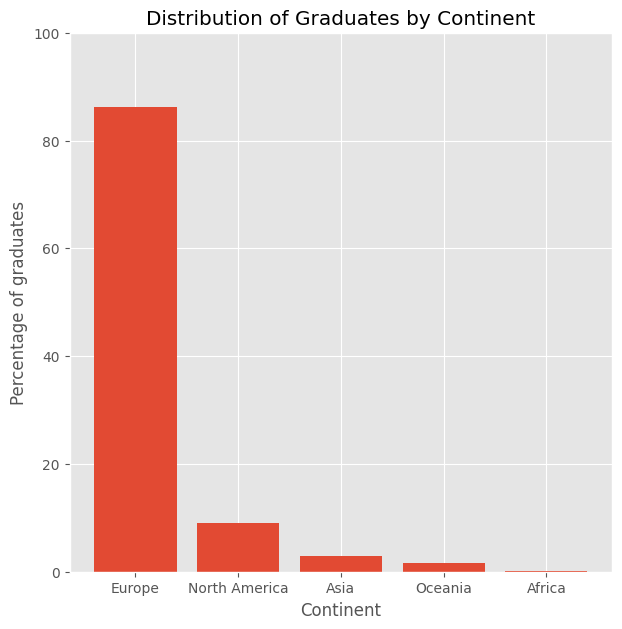

In [80]:
plt.figure(figsize=(7, 7))
# how many in each continent
counts = students["Continent"].value_counts().reset_index()
counts.columns = ["Continent", "count"]
counts["percent"] = counts["count"] / counts["count"].sum() * 100
# plt.pie(counts["Continent"], labels=counts["index"], autopct="%1.1f%%")
plt.bar(
    x=counts["Continent"].to_list(),
    height=counts["percent"],
)
plt.title("Distribution of Graduates by Continent")
plt.ylim(0, 100)
plt.xlabel("Continent")
plt.ylabel("Percentage of graduates")
plt.savefig(f"{figures}continent_pie.png")
plt.show()

The overwhelming majority are (perhaps predictably) in Europe, with North America far behind in second place. Let's break that down by country.

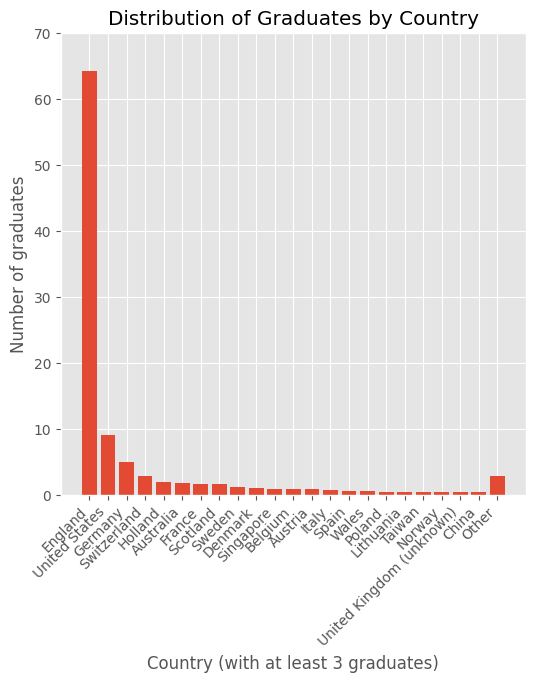

In [81]:
# graduates by country
plt.figure(figsize=(6, 6))
limit = 3
counts = students["Country"].value_counts().reset_index()
counts = counts.sort_values("count", ascending=False)
counts["percent"] = counts["count"] / counts["count"].sum() * 100
other = counts[counts["count"] < limit]
counts = counts[counts["count"] >= limit]
counts.loc[len(counts)] = ["Other", other["count"].sum(), other["percent"].sum()]
# plt.pie(counts["Country"], labels=counts["index"], autopct="%1.1f%%")
plt.bar(x=counts["Country"], height=counts["percent"])
plt.title("Distribution of Graduates by Country")
plt.xlabel("Country (with at least 3 graduates)")
plt.ylabel("Number of graduates")
plt.xticks(rotation=45, ha="right")
plt.savefig(f"{figures}country_pie.png")
plt.ylim(0, 70)
plt.show()

Unsurprisingly, the UK is the most popular destination. The pie chart also shows that the overwhelming majority of students in North America are in the US.

We can take a quick look at where graduates have gone outside of the UK in Europe.

Germany is the most popular destination, with Switzerland and Holland following behind.

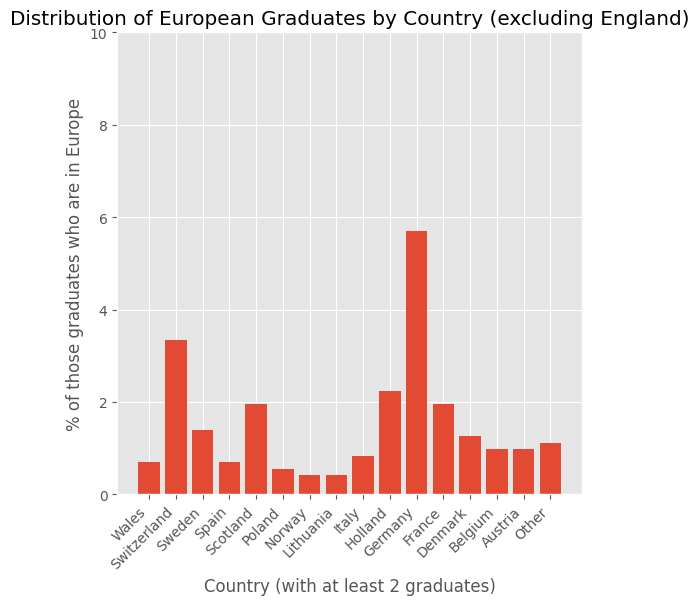

In [82]:
plt.figure(figsize=(6, 6))
# europe without the UK
limit = 2
counts = (
    students[students["Continent"] == "Europe"]["Country"].value_counts().reset_index()
)
counts = counts.sort_values("Country", ascending=False)
counts["percent"] = counts["count"] / counts["count"].sum() * 100
counts = counts[counts["Country"] != "England"]
counts = counts[counts["Country"] != "United Kingdom (unknown)"]
other = counts[counts["count"] < limit]
counts = counts[counts["count"] > limit]
counts.loc[len(counts)] = ["Other", other["count"].sum(), other["percent"].sum()]
# plt.pie(counts["count"], labels=counts["Country"], autopct="%1.1f%%")
plt.bar(x=counts["Country"], height=counts["percent"])
plt.title("Distribution of European Graduates by Country (excluding England)")
plt.xlabel("Country (with at least 2 graduates)")
plt.ylabel("% of those graduates who are in Europe")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 10)
plt.savefig(f"{figures}europe_nouk_country_pie.png")
plt.show()

And where graduates have gone OUTSIDE Europe...

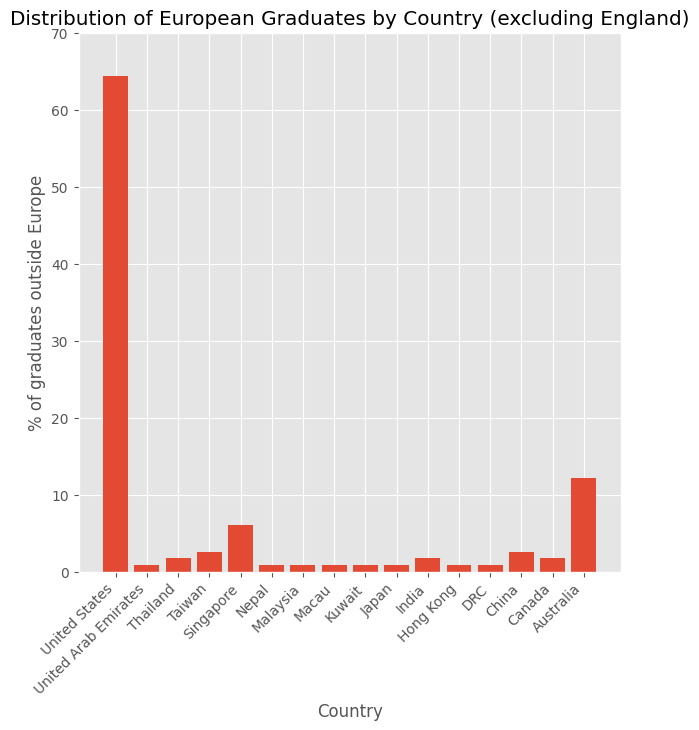

In [83]:
plt.figure(figsize=(7, 7))
# europe without the UK
limit = 0
counts = (
    students[students["Continent"] != "Europe"]["Country"].value_counts().reset_index()
)
counts = counts.sort_values("Country", ascending=False)
counts["percent"] = counts["count"] / counts["count"].sum() * 100
# plt.pie(counts["count"], labels=counts["Country"], autopct="%1.1f%%")
plt.bar(x=counts["Country"], height=counts["percent"])
plt.title("Distribution of European Graduates by Country (excluding England)")
plt.xlabel("Country")
plt.ylabel("% of graduates outside Europe")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 70)
plt.savefig(f"{figures}europe_nouk_country_pie.png")
plt.show()

Finally, we can look at where graduates have gone in the UK.

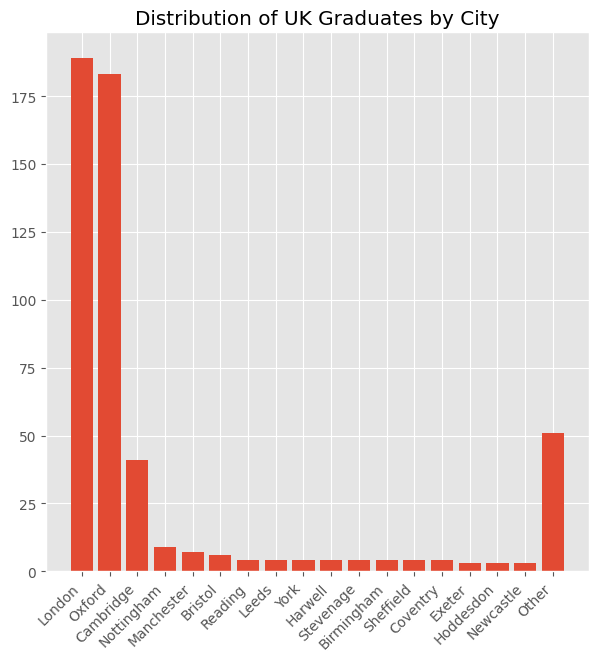

In [84]:
plt.figure(figsize=(7, 7))
# if UK, where are they?
limit = 2
counts = students[students["Country"] == "England"]["City"].value_counts().reset_index()
counts.columns = ["index", "City"]
counts = counts.sort_values("City", ascending=False)
other = counts[counts["City"] < limit]
counts = counts[counts["City"] > limit]
counts.loc[len(counts)] = ["Other", other["City"].sum()]
plt.bar(counts["index"], counts["City"])
# plt.pie(counts["City"], labels=counts["index"], autopct="%1.1f%%")
# plt.axis("equal")
plt.title("Distribution of UK Graduates by City")
plt.savefig(f"{figures}uk_city_pie.png")
# rotate x labels
plt.xticks(rotation=45, ha="right")
plt.show()


We can also look at whether graduates remained in the same country as that which they studied in prior to the DTC.
Additionally, did people stay in Oxford specifically? That is, if they studied in Oxford prior to the DTC, did they stay in Oxford? If they didn't, did they remain there after leaving the DTC?

In [85]:
# plotly sankey diagram for where students were before and after the course
counts = students.loc[:, ["PGUniversity", "City"]]
counts["last_known"] = counts["PGUniversity"].copy()
counts.loc[counts["last_known"].isna(), "last_known"] = students["UGUniversity"]
counts["place"] = None
counts.loc[counts["last_known"] == counts["City"], "place"] = "Stayed (Other)"
counts.loc[counts["last_known"] != counts["City"], "place"] = "Moved (Other)"
counts.loc[(counts["last_known"].isna()) & (counts["City"].isna()), "place"] = (
    "Not Known"
)
counts.loc[(counts["last_known"] == 0) & (counts["City"] == 0), "place"] = "Not Known"
counts.loc[
    (counts["last_known"] == "Oxford") & (counts["City"] == "Oxford"), "place"
] = "Stayed in Oxford"
counts.loc[
    (counts["last_known"] != "Oxford") & (counts["City"] == "Oxford"), "place"
] = "Moved to Oxford"
counts.loc[
    (counts["last_known"] == "Oxford") & (counts["City"] != "Oxford"), "place"
] = "Moved from Oxford"
counts.loc[(counts["last_known"].isna()) & (counts["City"] != "Oxford"), "place"] = (
    "Unknown to Elsewhere"
)
counts.loc[(counts["last_known"].isna()) & (counts["City"] == "Oxford"), "place"] = (
    "Unknown to Oxford"
)
counts.loc[(counts["last_known"] == "Oxford") & (counts["City"].isna()), "place"] = (
    "Oxford to Unknown"
)
counts.loc[(counts["last_known"] != "Oxford") & (counts["City"].isna()), "place"] = (
    "Elsewhere to Unknown"
)

counts = counts["place"].value_counts().reset_index()
counts.columns = ["index", "place"]
# set index to 'index' column
counts = counts.set_index("index")
counts = counts.T
display(counts)

not_known_at_all = counts["Not Known"] if "Not Known" in counts else 0

labels = ["Oxford", "Elsewhere", "Not Known", "Oxford", "Elsewhere", "Not Known"]
sources = [0, 0, 0, 1, 1, 1, 2, 2, 2]
target = [3, 4, 5, 3, 4, 5, 3, 4, 5]
value = [
    counts["Stayed in Oxford"],
    counts["Moved from Oxford"],
    counts["Oxford to Unknown"],
    counts["Moved to Oxford"],
    counts["Moved (Other)"],
    counts["Elsewhere to Unknown"],
    counts["Unknown to Oxford"],
    counts["Unknown to Elsewhere"],
    not_known_at_all,
]

label_color = [
    "steelblue",
    "crimson",
    "yellowgreen",
    "steelblue",
    "crimson",
    "yellowgreen",
]
link_color = [
    "steelblue",
    "orchid",
    "darkcyan",
    "purple",
    "crimson",
    "maroon",
    "grey",
    "turquoise",
    "yellowgreen",
]

node = dict(
    label=labels,
    color=label_color,
    pad=15,
    thickness=15,
    line=dict(color="black", width=0.5),
)
link = dict(source=sources, target=target, value=value, color=link_color)
figure = go.Figure(go.Sankey(link=link, node=node))
figure.show()

index,Moved (Other),Elsewhere to Unknown,Moved from Oxford,Moved to Oxford,Stayed in Oxford,Stayed (Other),Unknown to Elsewhere,Unknown to Oxford,Oxford to Unknown
place,467,206,164,140,41,10,5,2,2


In [86]:
# plotly sankey diagram for where students were before and after the course
counts = students.loc[:, ["PGCountry", "Country"]]
counts["last_known"] = counts["PGCountry"].copy()
counts.loc[counts["last_known"].isna(), "last_known"] = students["UGCountry"]
counts["place"] = None
counts.loc[counts["last_known"] == counts["Country"], "place"] = "Stayed (Other)"
counts.loc[counts["last_known"] != counts["Country"], "place"] = "Moved (Other)"
counts.loc[(counts["last_known"].isna()) & (counts["Country"].isna()), "place"] = (
    "Not Known"
)
counts.loc[(counts["last_known"] == 0) & (counts["Country"] == 0), "place"] = (
    "Not Known"
)
counts.loc[
    (counts["last_known"] == "England") & (counts["Country"] == "England"), "place"
] = "Stayed in England"

print(counts[counts["last_known"] == "England"].shape)
print(counts[counts["Country"] == "England"].shape)

counts.loc[
    (counts["last_known"] != "England") & (counts["Country"] == "England"), "place"
] = "Moved to England"
counts.loc[
    (counts["last_known"] == "England") & (counts["Country"] != "England"), "place"
] = "Moved from England"
counts.loc[
    (counts["last_known"].isna()) & (counts["Country"] != "England"), "place"
] = "Unknown to Elsewhere"
counts.loc[
    (counts["last_known"].isna()) & (counts["Country"] == "England"), "place"
] = "Unknown to England"
counts.loc[
    (counts["last_known"] == "England") & (counts["Country"].isna()), "place"
] = "England to Unknown"
counts.loc[
    (counts["last_known"] != "England") & (counts["Country"].isna()), "place"
] = "Elsewhere to Unknown"

counts = counts["place"].value_counts().reset_index()
counts.columns = ["index", "place"]
# set index to 'index' column
counts = counts.set_index("index")
counts = counts.T

not_known_at_all = counts["Not Known"] if "Not Known" in counts else 0

labels = ["England", "Elsewhere", "Not Known", "England", "Elsewhere", "Not Known"]
sources = [0, 0, 0, 1, 1, 1, 2, 2, 2]
target = [3, 4, 5, 3, 4, 5, 3, 4, 5]
value = [
    counts["Stayed in England"],
    counts["Moved from England"],
    counts["England to Unknown"],
    counts["Moved to England"],
    counts["Moved (Other)"],
    counts["Elsewhere to Unknown"],
    counts["Unknown to England"],
    counts["Unknown to Elsewhere"],
    not_known_at_all,
]

label_color = [
    "steelblue",
    "crimson",
    "yellowgreen",
    "steelblue",
    "crimson",
    "yellowgreen",
]
link_color = [
    "steelblue",
    "orchid",
    "darkcyan",
    "purple",
    "crimson",
    "maroon",
    "grey",
    "turquoise",
    "yellowgreen",
]

node = dict(
    label=labels,
    color=label_color,
    pad=15,
    thickness=15,
    line=dict(color="black", width=0.5),
)
link = dict(source=sources, target=target, value=value, color=link_color)
figure = go.Figure(go.Sankey(link=link, node=node))
figure.show()

(455, 4)
(535, 4)


## What are they doing?
The following plot shows the distribution of graduates' current sector.

Most graduates are in the 'Academic' sector, with 'Research' and 'Pharma' following behind.

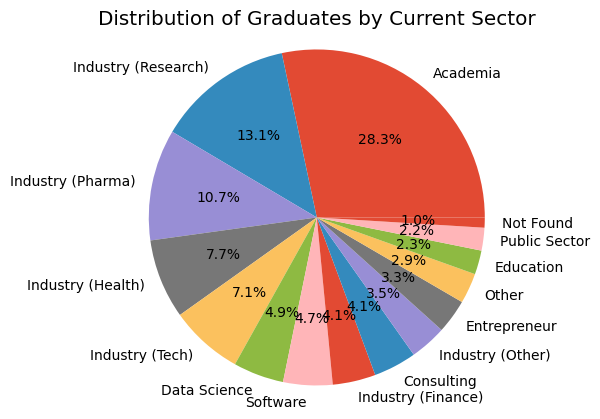

In [87]:
# graduates by sector
counts = students["Sector"].value_counts().reset_index()
plt.pie(counts["count"], labels=counts["Sector"], autopct="%1.1f%%")
plt.axis("equal")
plt.title("Distribution of Graduates by Current Sector")
plt.savefig(f"{figures}sector_pie.png")
plt.show()

## Past jobs


In [88]:
display(jobs.Sector.value_counts().to_frame())

,count
Sector,
Academia,690
Industry (Pharma),162
Industry (Health),104
Consulting,103
Industry (Research),99
Industry (Biotech),95
Industry (Tech),84
Industry (Finance),70
Data Science,70


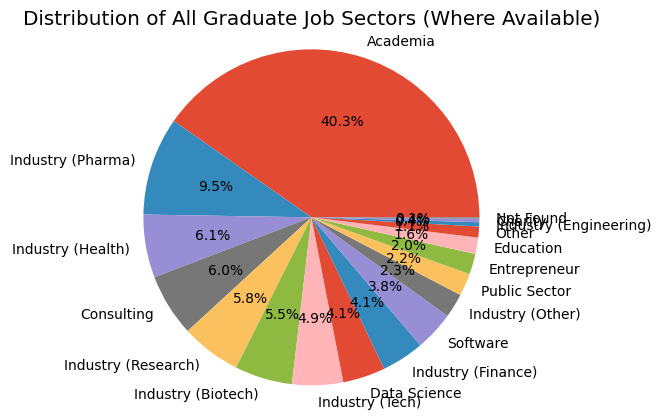

In [89]:
available_sectors = [
    "Academia",
    "Industry (Pharma)",
    "Industry (Research)",
    "Consulting",
    "Industry (Health)",
    "Industry (Tech)",
    "Industry (Biotech)",
    "Data Science",
    "Industry (Finance)",
    "Software",
    "Entrepreneur",
    "Industry (Other)",
    "Public Sector",
    "Other",
    "Education",
    "Industry (Engineering)",
    "Charity",
    "Not Found",
]
jobs_with_correct_sectors = jobs.loc[jobs["Sector"].isin(available_sectors)]

# pie chart of sectors
counts = jobs_with_correct_sectors["Sector"].value_counts().reset_index()
plt.pie(counts["count"], labels=counts["Sector"], autopct="%1.1f%%")
plt.axis("equal")
plt.title("Distribution of All Graduate Job Sectors (Where Available)")
plt.savefig(f"{figures}sector_pie.png")
plt.show()

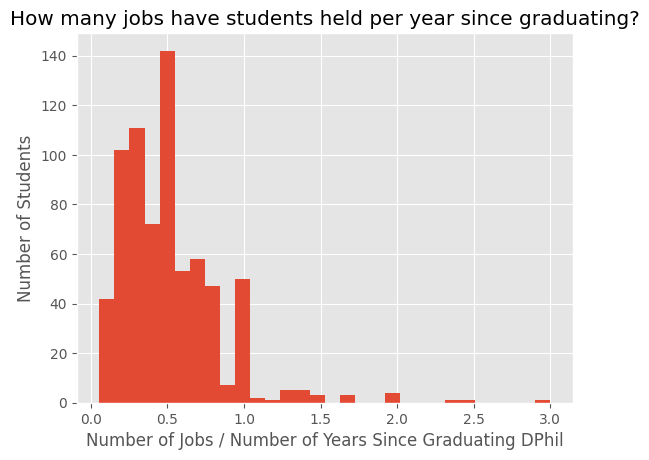

NB some roles are held concurrently. This is not accounted for in the above plot.


In [90]:
current_year = datetime.now().year
num_jobs_stand = jobs["Name"].value_counts().reset_index()
num_jobs_stand["Year"] = None

num_jobs_stand = num_jobs_stand.loc[num_jobs_stand["Year"] != 0]
for name in num_jobs_stand["Name"]:
    relevant_row = students.loc[students.Name == name]
    # Check if the relevant row is empty
    year = relevant_row["Thesis Year"].values[0]
    if pd.isna(year):
        num_jobs_stand.loc[num_jobs_stand["Name"] == name, "Year"] = current_year
    else:
        num_jobs_stand.loc[num_jobs_stand["Name"] == name, "Year"] = year
num_jobs_stand["years_to_job_start"] = current_year - num_jobs_stand["Year"].copy()
num_jobs_stand["jobs_time"] = num_jobs_stand["count"] / num_jobs_stand["years_to_job_start"]
num_jobs_stand.jobs_time.plot(kind="hist", bins=30)
plt.title("How many jobs have students held per year since graduating?")
plt.xlabel("Number of Jobs / Number of Years Since Graduating DPhil")
plt.ylabel("Number of Students")
plt.show()

print(
    "NB some roles are held concurrently. This is not accounted for in the above plot."
)

## Career progression

381


,time_to_leave,count
0,Never left,164
1,2.0,35
2,0.0,63
3,10.0,2
4,3.0,20
5,1.0,65
6,8.0,3
7,5.0,12
8,7.0,3
9,4.0,11


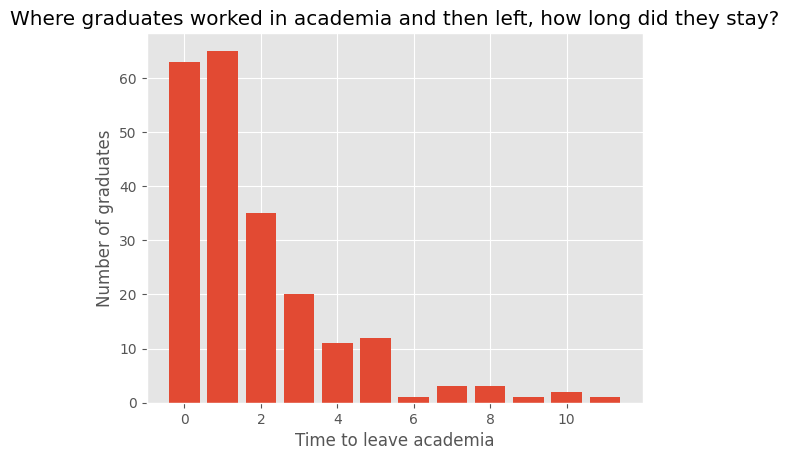

,Name,time_to_leave,years_to_job_start,years_since
0,Danny Axford,Never left,NaN,18.0
1,Ben Lambert,Never left,NaN,8.0
2,Ivor Simpson,2.0,NaN,NaN
3,Maria Ordovas-Montanes,0.0,NaN,NaN
4,Joanna Gay,10.0,NaN,NaN
...,...,...,...,...
376,Sean Guggiari,0.0,NaN,NaN
377,Anna Booth,Never left,NaN,3.0
378,Beatriz Moreno Garcia,Never left,NaN,5.0
379,James Osborne,Never left,NaN,16.0


,years_since,count
0,18.0,2
1,8.0,10
2,11.0,6
3,2.0,24
4,4.0,25
5,5.0,12
6,13.0,4
7,10.0,8
8,12.0,3
9,6.0,15


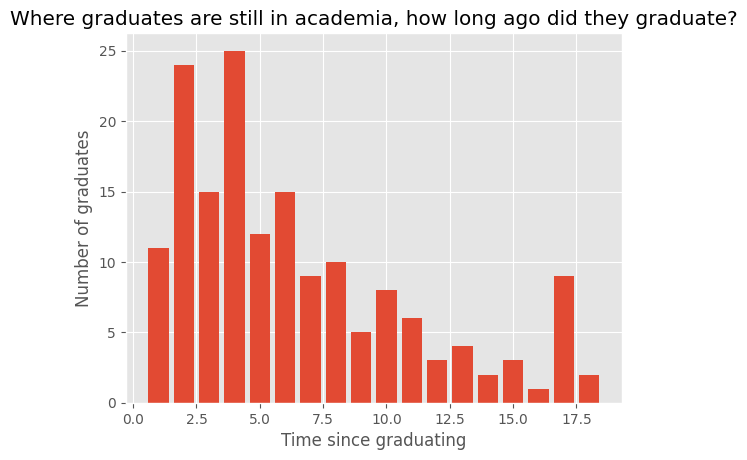

/var/folders/zk/7wt7hny90bjd8lg6jxjt4fkc0000gr/T/ipykernel_32767/4146181923.py:98: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'England' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.



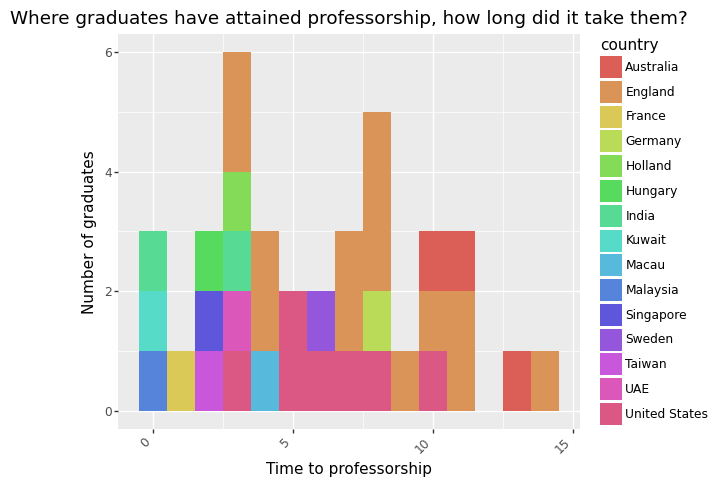

In [ ]:
academia_subset = jobs.copy()
to_exclude = []

for name in academia_subset["Name"]:
    relevant_subset = academia_subset.loc[academia_subset.Name == name]
    # check if ever worked in academia
    if relevant_subset["Sector"].str.contains("Academia").any():
        pass
    else:
        to_exclude.append(name)

# remove those who have never worked in academia
academia_subset = academia_subset[~academia_subset["Name"].isin(to_exclude)]

print(academia_subset.Name.nunique())

academia_time = pd.DataFrame()
academia_time["Name"] = academia_subset["Name"].unique()

academia_time["time_to_leave"] = np.nan
academia_time["years_to_job_start"] = np.nan

for name in academia_time.Name:
    relevant_rows = academia_subset.loc[academia_subset.Name == name]
    # check the time of the first non-academic job
    non_academia_jobs = relevant_rows[relevant_rows["Sector"] != "Academia"]
    if non_academia_jobs.shape[0] == 0:
        academia_time.loc[academia_time["Name"] == name, "time_to_leave"] = np.nan
        academia_time.loc[academia_time["Name"] == name, "years_since"] = (
            relevant_rows["years_since"].min()
        )
    else:
        time_to_leave = non_academia_jobs["years_to_job_start"].min()
        academia_time.loc[academia_time["Name"] == name, "time_to_leave"] = (
            time_to_leave
        )

academia_time.time_to_leave = academia_time.time_to_leave.astype(object)
academia_time.time_to_leave = academia_time.time_to_leave.replace(
    {np.nan: "Never left"}
)

counts = academia_time.time_to_leave.value_counts(sort=False).reset_index()
# sort index
display(counts)
counts = counts[counts.time_to_leave != "Never left"]
counts = counts.sort_values(by="time_to_leave")
plt.bar(
    x=counts["time_to_leave"],
    height=counts["count"],
)

plt.title("Where graduates worked in academia and then left, how long did they stay?")
plt.xlabel("Time to leave academia")
plt.ylabel("Number of graduates")
plt.show()

# histogram of years since graduating
display(academia_time)
counts = academia_time.dropna(subset='years_since').years_since.value_counts(sort=False).reset_index()
counts = counts.sort_values(by="years_since")
plt.bar(
    x=counts["years_since"],
    height=counts["count"],
)

plt.title("Where graduates are still in academia, how long ago did they graduate?")
plt.xlabel("Time since graduating")
plt.ylabel("Number of graduates")
plt.show()


# time to professorship
professorship = pd.DataFrame()
professorship["Name"] = academia_subset["Name"].unique()
professorship["time_to_prof"] = np.nan
professorship["country"] = np.nan
for name in professorship.Name:
    relevant_rows = academia_subset.loc[academia_subset.Name == name]
    relevant_rows = relevant_rows.dropna(subset="Job Title")

    # check the time of the first non-academic job
    any_prof_job = (
        sum(["professor" in i.lower() for i in relevant_rows["Job Title"]]) > 0
    )
    if any_prof_job:
        prof_jobs = relevant_rows[
            relevant_rows["Job Title"].str.contains("professor", case=False)
        ]
        time_to_prof = prof_jobs["years_to_job_start"].min()
        prof_country = prof_jobs.loc[prof_jobs["years_to_job_start"] == time_to_prof, "Country"].values[0]
    else:
        time_to_prof = np.nan
        prof_country = np.nan

    professorship.loc[professorship["Name"] == name, "time_to_prof"] = time_to_prof
    professorship.loc[professorship["Name"] == name, "country"] = prof_country

# professorship.time_to_prof = professorship.time_to_prof.astype(object)
# professorship.time_to_prof = professorship.time_to_prof.replace({np.nan: 'Never became professor'})
professorship = professorship.dropna(subset="time_to_prof")

# histogram of time_to_prof coloured by country
hist = (ggplot(professorship, aes(x='time_to_prof', fill='country')) 
    + p9.geom_histogram(binwidth=1)
    + p9.ggtitle("Where graduates have attained professorship, how long did it take them?")
    + p9.xlab("Time to professorship")
    + p9.ylab("Number of graduates")
    + p9.theme(axis_text_x=p9.element_text(rotation=45, hjust=1))
)
hist.draw()

# # bar chart
# counts = professorship.time_to_prof.value_counts(sort=False).reset_index()
# display(counts)
# counts = counts.sort_values(by="time_to_prof")
# plt.bar(
#     x=counts["time_to_prof"],
#     height=counts["count"],
# )
# plt.title("Where graduates have attained professorship, how long it take them?")
# # do a histogram coloured by country
# plt.xlabel("Time to professorship")
# plt.ylabel("Number of graduates")
# plt.show()

In [120]:
has_professorship = jobs[jobs.Name.isin(professorship.Name)]
has_professorship.to_csv(f"{output}has_professorship.csv", index=False)

In [117]:
# where graduates have wworked as a postdoc, how long did they stay?
postdoc = pd.DataFrame()
postdoc["Name"] = academia_subset["Name"].unique()
postdoc["time_as_postdoc"] = np.nan


for name in postdoc.Name:
    relevant_rows = academia_subset.loc[academia_subset.Name == name]
    relevant_rows = relevant_rows.dropna(subset="Job Title")

    # check the time of the first non-academic job
    any_postdoc_job = (
        sum(["postdoc" in i.lower() for i in relevant_rows["Job Title"]]) > 0
    )
    if any_postdoc_job:
        postdoc_jobs = relevant_rows[
            ['postdoc' in i.lower() for i in relevant_rows["Job Title"]]
        ]
        
        postdoc_jobs["End date"] = pd.to_datetime(postdoc_jobs["End date"], errors='coerce')
        postdoc_jobs["Start date"] = pd.to_datetime(postdoc_jobs["Start date"], errors='coerce')

        print(name, postdoc_jobs['Start date'].unique(), postdoc_jobs['End date'].unique())
        postdoc_start = postdoc_jobs["Start date"].min()
        postdoc_jobs["End date"] = postdoc_jobs["End date"].replace(
            {np.nan: current_year, 'Present': current_year, 'present': current_year}
        )
        postdoc_end = postdoc_jobs["End date"].max()
        try:
            time_as_postdoc = postdoc_end - postdoc_start
            # set time_as_postdoc to the number of years
            time_as_postdoc = time_as_postdoc.days / 365
        except Exception as e:
            time_as_postdoc = np.nan
    else:
        time_as_postdoc = np.nan

    postdoc.loc[postdoc["Name"] == name, "time_as_postdoc"] = time_as_postdoc

counts = postdoc.time_as_postdoc.value_counts(sort=False).reset_index()
display(counts)

Ben Lambert <DatetimeArray>
['2017-10-01 00:00:00']
Length: 1, dtype: datetime64[ns] <DatetimeArray>
['2020-12-01 00:00:00']
Length: 1, dtype: datetime64[ns]
Ivor Simpson <DatetimeArray>
['2012-11-01 00:00:00']
Length: 1, dtype: datetime64[ns] <DatetimeArray>
['2014-09-01 00:00:00']
Length: 1, dtype: datetime64[ns]
Abigail Guillermo <DatetimeArray>
['2019-11-01 00:00:00']
Length: 1, dtype: datetime64[ns] <DatetimeArray>
['2020-11-01 00:00:00']
Length: 1, dtype: datetime64[ns]
Nasir Ahmad <DatetimeArray>
['2019-10-01 00:00:00']
Length: 1, dtype: datetime64[ns] <DatetimeArray>
['2022-10-01 00:00:00']
Length: 1, dtype: datetime64[ns]
Jonathan Harrison <DatetimeArray>
['2019-01-01 00:00:00']
Length: 1, dtype: datetime64[ns] <DatetimeArray>
['2022-07-01 00:00:00']
Length: 1, dtype: datetime64[ns]
Rehan Ali <DatetimeArray>
['2009-04-01 00:00:00']
Length: 1, dtype: datetime64[ns] <DatetimeArray>
['2009-11-01 00:00:00']
Length: 1, dtype: datetime64[ns]
Adrian Groves <DatetimeArray>
['2010-02-0

/var/folders/zk/7wt7hny90bjd8lg6jxjt4fkc0000gr/T/ipykernel_32767/41476682.py:20: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/zk/7wt7hny90bjd8lg6jxjt4fkc0000gr/T/ipykernel_32767/41476682.py:21: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/zk/7wt7hny90bjd8lg6jxjt4fkc0000gr/T/ipykernel_32767/41476682.py:25: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docu

TypeError: '>=' not supported between instances of 'int' and 'Timestamp'

,count
Company,
university of oxford,543
imperial college london,20
ucl,19
university of cambridge,19
oxford nanopore technologies,17
benevolentai,16
gsk,16
kcl,15
perspectum,14


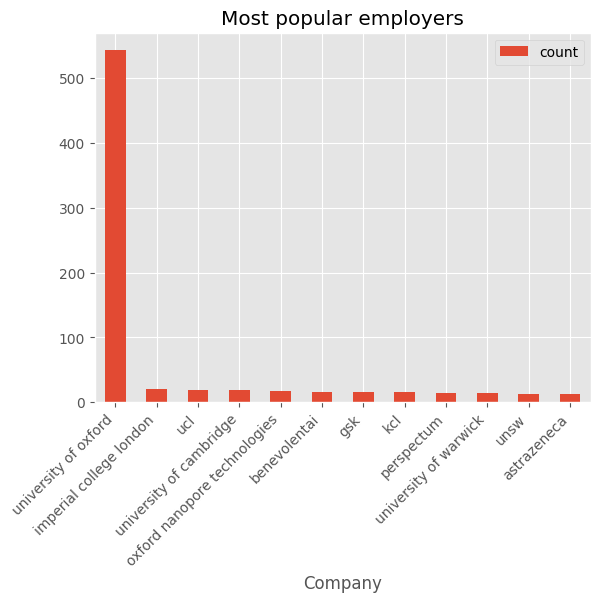

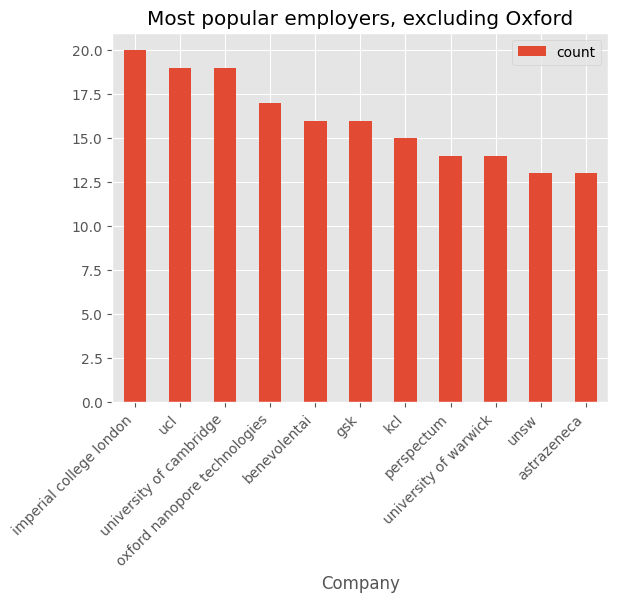

In [92]:
# ensure only jobs held SINCE graduating
employers = jobs.Company.dropna().str.lower()


for i, name in enumerate(employers):
    if "university of oxford" in name:
        print
        employers.loc[i] = "university of oxford"
    elif "college oxford" in name:
        employers.loc[i] = "university of oxford"
    else:
        pass

counts = employers.value_counts().to_frame()
counts = counts.loc[counts["count"] > 10]
display(counts)
counts.plot.bar()
plt.title("Most popular employers")
plt.xticks(rotation=45, ha="right")
plt.show()

# exclude oxford
counts[counts.index != "university of oxford"].plot.bar()
plt.title("Most popular employers, excluding Oxford")
plt.xticks(rotation=45, ha="right")
plt.show()

In [118]:
students.shape

(1037, 27)

,count
Job Title,
postdoctoral researcher,173
postdoctoral research fellow,52
postdoctoral research associate,50
data scientist,47
senior scientist,41
consultant,33
research scientist,28
senior data scientist,25
research fellow,25


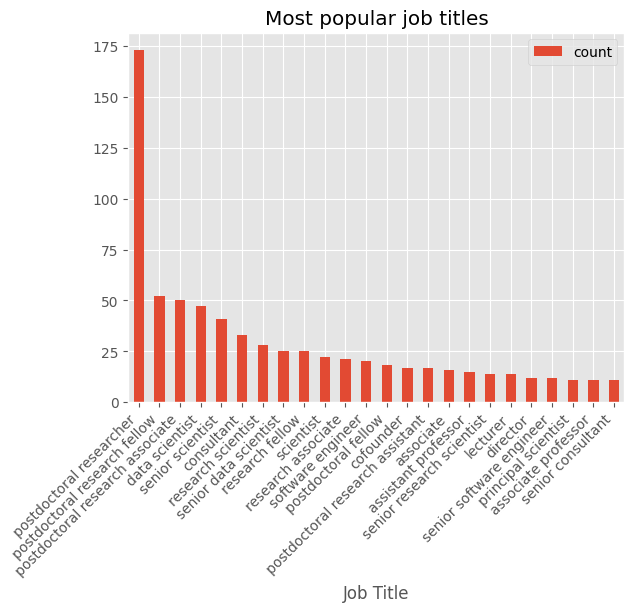

In [93]:
# top job titles
job_titles = jobs["Job Title"].dropna().str.lower()
counts = job_titles.value_counts().to_frame()
counts = counts.loc[counts["count"] > 10]
display(counts)
counts.plot.bar()
plt.title("Most popular job titles")
plt.xticks(rotation=45, ha="right")
plt.show()

In [ ]:
# entrepreneurs

entrepreneurs = jobs[jobs.Sector=='Entrepreneur'].reset_index(drop=True).sort_values(by="Name")
# display(entrepreneurs.Name.value_counts().to_frame())
# display(entrepreneurs.Company.value_counts().to_frame())
entrepreneurs_shared = {}
for company in entrepreneurs.Company.unique():
    entrepreneurs_shared[company] = jobs[jobs.Company == company].shape[0]
    
entrepreneurs_shared = pd.DataFrame.from_dict(entrepreneurs_shared, orient='index', columns=['count'])
entrepreneurs_shared = entrepreneurs_shared.sort_values(by='count', ascending=False)
entrepreneurs_shared = entrepreneurs_shared[entrepreneurs_shared['count'] > 1]
display(entrepreneurs_shared)


,count
Entrepreneur First,6
Wild Bioscience,4
Relation,3
Innersight Labs Ltd,3
Stealth Startup,3
InnersightLabs,2
Royal Academy of Engineering,2
Optellum,2
Oxford Science Innovation,2


In [100]:
education = jobs[jobs.Sector == "Education"].reset_index(drop=True)
display(education.Company.value_counts().to_frame())

,count
Company,
Decoded,4
Schmidt Science Fellows,2
Claremont Preparatory School,1
Haberdashers' Adams,1
London Metropolian University,1
HRH princess Chulabhorn College,1
STM,1
Eton College,1
Madeley Academy,1
